<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1I8kDikouqpH4hf7JBiSYAeNT2IO52T-T" width=600 height=480/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Generative adversarial networks</b></h3>



В этом домашнем задании вы обучите GAN генерировать лица людей и посмотрите на то, как можно оценивать качество генерации

In [18]:
import os
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import pairwise_distances_chunked
import torchvision.transforms as tt
import torch
import torch.nn as nn
import cv2
from tqdm.notebook import tqdm
from torchvision.utils import save_image
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set(style='darkgrid', font_scale=1.2)

## Часть 1. Подготовка данных (1 балл)

В качестве обучающей выборки возьмем часть датасета [Flickr Faces](https://github.com/NVlabs/ffhq-dataset), который содержит изображения лиц людей в высоком разрешении (1024х1024). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно [здесь](https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory) и  [здесь](https://drive.google.com/file/d/1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x/view?usp=drive_link)

Давайте загрузим наши изображения. Напишите функцию, которая строит DataLoader для изображений, при этом меняя их размер до нужного значения (размер 1024 слишком большой, поэтому мы рекомендуем взять размер 128 либо немного больше)

In [19]:
import kagglehub

path = kagglehub.dataset_download("tommykamaz/faces-dataset-small")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'faces-dataset-small' dataset.
Path to dataset files: /kaggle/input/faces-dataset-small


In [20]:
def get_dataloader(image_size, batch_size):
  """
  Builds dataloader for training data.
  Use tt.Compose and tt.Resize for transformations
  :param image_size: height and wdith of the image
  :param batch_size: batch_size of the dataloader
  :returns: DataLoader object
  """
  # TODO: resize images, convert them to tensors and build dataloader
  transform = tt.Compose([
        tt.Resize((image_size, image_size)),
        tt.ToTensor()])
  dataset = ImageFolder(
        root=path,
        transform=transform)
  dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )
  return dataloader

In [21]:
image_size = 128

batch_size = 64

train_loader = get_dataloader(image_size=image_size, batch_size=batch_size)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Часть 2. Построение и обучение модели (4 балла)

Сконструируйте генератор и дискриминатор. Помните, что:
* дискриминатор принимает на вход изображение (тензор размера `3 x image_size x image_size`) и выдает вероятность того, что изображение настоящее (тензор размера 1)

* генератор принимает на вход тензор шумов размера `latent_size x 1 x 1` и генерирует изображение размера `3 x image_size x image_size`

In [22]:
discriminator = nn.Sequential(
    nn.Conv2d(3, 64, 4, 2, 1, bias=False),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(64, 128, 4, 2, 1, bias=False),
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(128, 256, 4, 2, 1, bias=False),
    nn.BatchNorm2d(256),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(256, 512, 4, 2, 1, bias=False),
    nn.BatchNorm2d(512),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(512, 1024, 4, 2, 1, bias=False),
    nn.BatchNorm2d(1024),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(1024, 1, 4, 1, 0, bias=False),
    nn.Sigmoid(),

    nn.Flatten())

In [23]:
latent_size = 100

generator = nn.Sequential(
    nn.ConvTranspose2d(latent_size, 1024, 4, 1, 0, bias=False),
    nn.BatchNorm2d(1024),
    nn.ReLU(True),

    nn.ConvTranspose2d(1024, 512, 4, 2, 1, bias=False),
    nn.BatchNorm2d(512),
    nn.ReLU(True),

    nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(True),

    nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(True),

    nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(True),

    nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
    nn.Tanh())

Перейдем теперь к обучению нашего GANа. Алгоритм обучения следующий:
1. Учим дискриминатор:
  * берем реальные изображения и присваиваем им метку 1
  * генерируем изображения генератором и присваиваем им метку 0
  * обучаем классификатор на два класса

2. Учим генератор:
  * генерируем изображения генератором и присваиваем им метку 0
  * предсказываем дискриминаторором, реальное это изображение или нет


В качестве функции потерь берем бинарную кросс-энтропию

In [24]:
lr = 0.0001

model = {
    "discriminator": discriminator,
    "generator": generator
}

criterion = {
    "discriminator": nn.BCELoss(),
    "generator": nn.BCELoss()
}

In [25]:
def fit(model, criterion, epochs, lr):
    generator = model["generator"].to(device)
    discriminator = model["discriminator"].to(device)

    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

    for epoch in range(epochs):
        generator.train()
        discriminator.train()

        for real_images, _ in train_loader:
            real_images = real_images.to(device)

            batch_size = real_images.size(0)

            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            opt_d.zero_grad()

            real_pred = discriminator(real_images)
            d_real_loss = criterion["discriminator"](real_pred, real_labels)

            noise = torch.randn(batch_size, latent_size, 1, 1, device=device)
            fake_images = generator(noise)

            fake_pred = discriminator(fake_images.detach())
            d_fake_loss = criterion["discriminator"](fake_pred, fake_labels)

            d_loss = d_real_loss + d_fake_loss
            d_loss.backward()
            opt_d.step()

            opt_g.zero_grad()

            noise = torch.randn(batch_size, latent_size, 1, 1, device=device)
            fake_images = generator(noise)

            pred = discriminator(fake_images)

            g_loss = criterion["generator"](pred, real_labels)

            g_loss.backward()
            opt_g.step()

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"D loss: {d_loss.item():.4f} "
            f"G loss: {g_loss.item():.4f}"
        )

In [26]:
epochs = 20

fit(
    model=model,
    criterion=criterion,
    epochs=epochs,
    lr=lr)

KeyboardInterrupt: 

In [ ]:
d_losses = [
    0.0005, 0.1355, 0.0004, 1.2678, 0.2140,
    0.7065, 0.5634, 0.3726, 1.4380, 0.0377,
    0.4045, 0.3655, 0.2375, 0.8219, 1.1030,
    0.5726, 1.4806, 0.0980, 0.7030, 0.1477
]

g_losses = [
    18.1869, 8.9150, 26.7947, 12.5488, 4.4809,
    5.5981, 21.6123, 2.9033, 4.1894, 5.8795,
    4.0742, 2.6588, 3.7596, 6.9162, 5.0073,
    3.9563, 2.8435, 3.1954, 4.1219, 4.1713
]

epochs = range(1, 21)

plt.figure(figsize=(10, 6))
plt.plot(epochs, d_losses, marker='o', label='Discriminator Loss')
plt.plot(epochs, g_losses, marker='o', label='Generator Loss')

plt.title('GAN Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

Постройте графики лосса для генератора и дискриминатора. Что вы можете сказать про эти графики? - Обучение было нестабильным, лосс не был убывающе монотонным, но к концу обучения все же снизился, что говорит о частичном улучшении качества генерации

## Часть 3. Генерация изображений

Теперь давайте оценим качество получившихся изображений. Напишите функцию, которая выводит изображения, сгенерированные нашим генератором

In [ ]:
n_images = 4

fixed_latent = torch.randn(n_images, latent_size, 1, 1, device=device)
fake_images = model["generator"](fixed_latent)

In [ ]:
def show_images(generated):
    generated = generated.detach().cpu()

    fig, axes = plt.subplots(1, len(generated), figsize=(4 * len(generated), 4))

    if len(generated) == 1:
        axes = [axes]

    for ax, img in zip(axes, generated):
        img = img.permute(1, 2, 0)

        ax.imshow((img + 1) / 2)
        ax.axis("off")

    plt.show()

In [ ]:
show_images(fake_images)

Как вам качество получившихся изображений? - Не очень!

## Часть 4. Leave-one-out-1-NN classifier accuracy (5 баллов)

### 4.1. Подсчет accuracy (3 балл)

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативы вам предлагается реализовать следующий подход:
  * Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить фейковым метку класса 0, настоящим – 1.
  * Построить leave-one-out оценку: обучить 1NN Classifier (`sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)`) предсказывать класс на всех объектах, кроме одного, проверить качество (accuracy) на оставшемся объекте. В этом вам поможет `sklearn.model_selection.LeaveOneOut`

In [ ]:
def calculate_loo_accuracy(generator, train_loader, latent_size, device):
    generator.eval()

    real_images = []

    for images, _ in train_loader:
        real_images.append(images)

    real_images = torch.cat(real_images, dim=0)

    n_real = len(real_images)

    with torch.no_grad():
        noise = torch.randn(n_real, latent_size, 1, 1, device=device)
        fake_images = generator(noise).cpu()

    X_real = real_images.reshape(n_real, -1).numpy().astype(np.float32)
    X_fake = fake_images.reshape(n_real, -1).numpy().astype(np.float32)

    X = np.vstack([X_real, X_fake])

    y = np.hstack([
        np.ones(n_real, dtype=np.int8),
        np.zeros(n_real, dtype=np.int8)
    ])

    correct = 0
    start = 0

    for chunk in pairwise_distances_chunked(X, metric="euclidean"):
        rows = chunk.shape[0]

        for i in range(rows):
            global_i = start + i

            chunk[i, global_i] = np.inf

            nn = np.argmin(chunk[i])

            if y[nn] == y[global_i]:
                correct += 1

        start += rows

    return correct / len(X)

In [ ]:
acc = calculate_loo_accuracy(
    model["generator"],
    train_loader,
    latent_size,
    device)

print(acc)

Что вы можете сказать о получившемся результате? Какой accuracy мы хотели бы получить и почему? - Полученный результат говорит о том, что классификатор в 94% случаев может отличить реальные изображения от сгенерированных. мы бы хотели получить accuracy, близкую к 0.5, что означало бы, что сгенерированные изображения трудно отличить от реальных

### 4.2. Визуализация распределений (2 балл)

Давайте посмотрим на то, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом, снижающим размерность (к примеру, TSNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображенияи

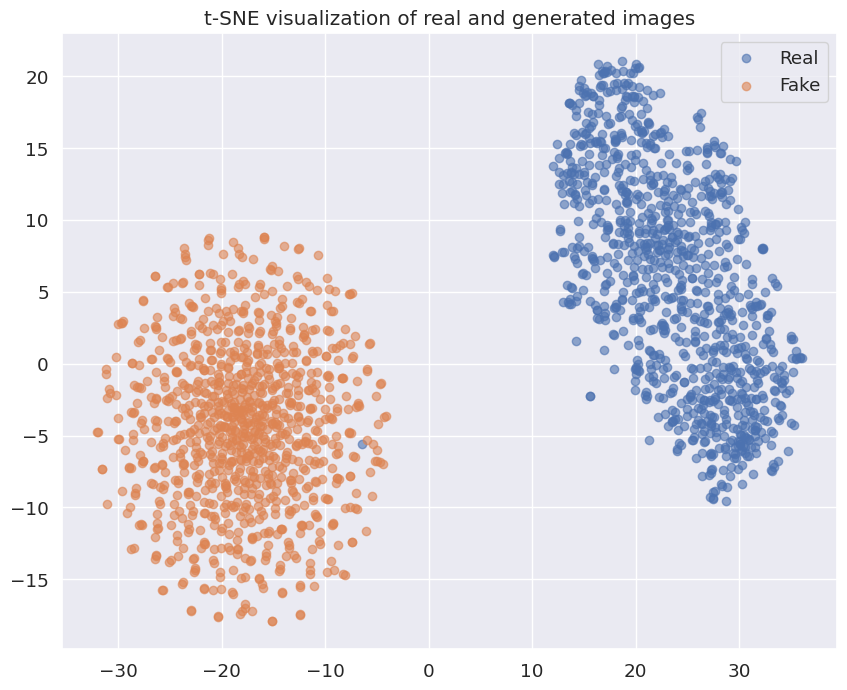

In [27]:
from sklearn.manifold import TSNE
generator = model["generator"]
generator.eval()

real_images = []

for images, _ in train_loader:
    real_images.append(images)

real_images = torch.cat(real_images, dim=0)

n_samples = 1000

real_images = real_images[:n_samples]

with torch.no_grad():
    noise = torch.randn(n_samples, latent_size, 1, 1, device=device)
    fake_images = generator(noise).cpu()

X_real = real_images.reshape(n_samples, -1).numpy()
X_fake = fake_images.reshape(n_samples, -1).numpy()

X = np.vstack([X_real, X_fake])

labels = np.hstack([
    np.ones(n_samples),
    np.zeros(n_samples)
])

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 8))

plt.scatter(
    X_tsne[labels == 1, 0],
    X_tsne[labels == 1, 1],
    label="Real",
    alpha=0.6
)

plt.scatter(
    X_tsne[labels == 0, 0],
    X_tsne[labels == 0, 1],
    label="Fake",
    alpha=0.6
)

plt.legend()
plt.title("t-SNE visualization of real and generated images")
plt.show()

Прокомментируйте получившийся результат:

Поскольку мы видим два явно разделенных кластера, мы можем сказать, что генератор не смог приблизить распределение сгенерированных изображений к распределению реальных